# Titanic Data Visualization Dashboard
### Created by: Shashi Reddy
### Internship Task – Data Science

This notebook performs data cleaning, feature engineering, and visual analysis on the Titanic dataset.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [13]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Overview

The Titanic dataset contains passenger information such as age, gender, ticket class, fare, and survival status.

In [14]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [15]:
# Fill missing Age with median
df['age'] = df['age'].fillna(df['age'].median())

# Fill missing Embarked with mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop deck column (too many missing values)
df = df.drop(columns=['deck'])

# Verify again
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [17]:
# Create Family Size feature
df['family_size'] = df['sibsp'] + df['parch']

# Create Age Group feature
df['age_group'] = pd.cut(df['age'],
                         bins=[0,12,18,35,60,100],
                         labels=['Child','Teen','Young Adult','Adult','Senior'])

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size,age_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,1,Young Adult
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,1,Adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,0,Young Adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,1,Young Adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,0,Young Adult


## Visualizations

Most passengers were between 20 and 40 years old.

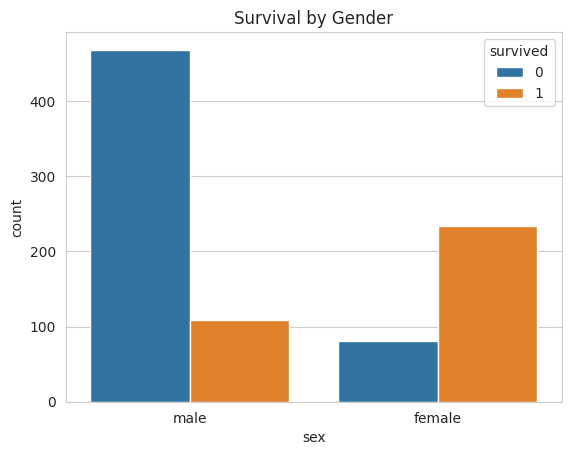

In [19]:
sns.countplot(x='sex', hue='survived', data=df)
plt.title("Survival by Gender")
plt.show()

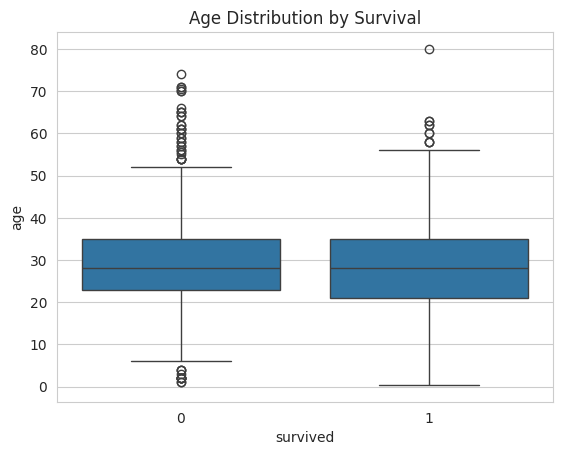

In [20]:
sns.boxplot(x='survived', y='age', data=df)
plt.title("Age Distribution by Survival")
plt.show()

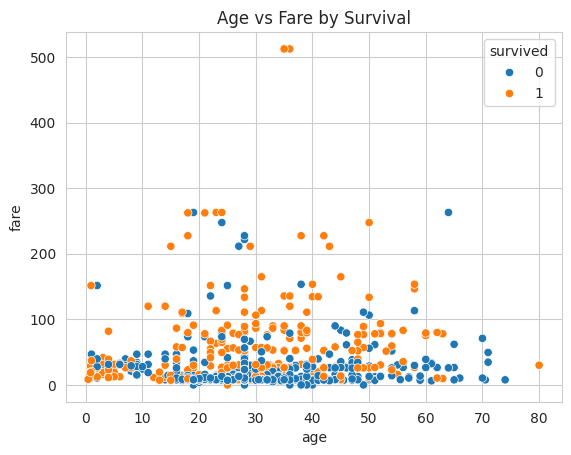

In [21]:
sns.scatterplot(x='age', y='fare', hue='survived', data=df)
plt.title("Age vs Fare by Survival")
plt.show()

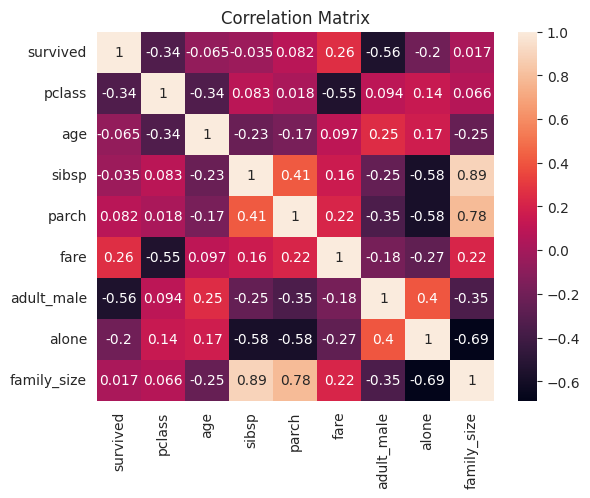

In [22]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

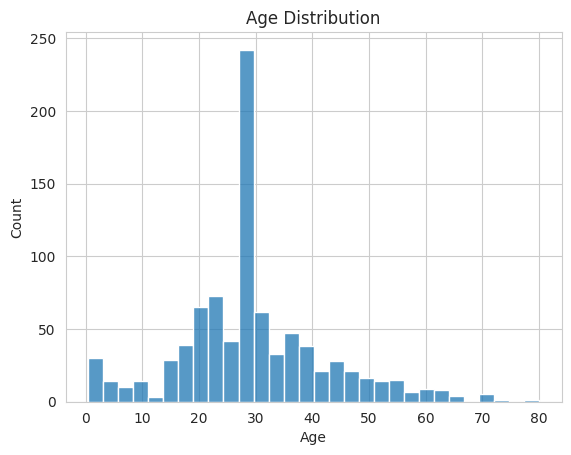

In [18]:
plt.figure()
sns.histplot(df['age'], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## Key Insights

- Gender was a major factor in survival.
- Higher class passengers had better survival rates.
- Fare positively influenced survival probability.
- Most passengers were young adults.

## Conclusion

The analysis shows that gender, passenger class, and fare significantly influenced survival on the Titanic.